<a href="https://colab.research.google.com/github/shahwaiz-9/Machine_Learning/blob/main/Text_Preproccessing_%26_Binary_Text_Classification_(_ML_)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Acquization**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [ ]:
import os

# List the files in the downloaded dataset directory
print(os.listdir(path))

['IMDB Dataset.csv']


In [ ]:
import pandas as pd

df = pd.read_csv(os.path.join(path, 'IMDB Dataset.csv'))

# Display the first 5 rows of the DataFrame
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


**Data Overview**

In [ ]:
df.shape

(50000, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
df.duplicated().sum()

np.int64(418)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Checking balance of classes

df['sentiment'].value_counts()


,count
sentiment,
positive,24884
negative,24698


Dataset is a balanced.

In [ ]:
pip install contractions

**Text Preprocessing**

In [ ]:
import re
import nltk
import contractions
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

In [ ]:

# Download once (if not already done)
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [ ]:
stopwords = nltk.corpus.stopwords.words('english')
lemmatizer = WordNetLemmatizer()


In [ ]:
df['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [ ]:
def clean_text(text):

  # Remove html tags
  text = re.sub(r'<.*?>', '', text)

  # Remove Url's

  text = re.sub(r'http\S+|www\S+|https\S+', '', text)

  # Correct Contraction eg don't -> do not

  text = contractions.fix(text)

  # Lower case

  text = text.lower()

  # Remove Punctuations

  text = re.sub(r'[^\w\s]', '', text)

  return text


In [ ]:
df['review'] = df['review'].apply(clean_text)

In [ ]:
df['review'][0]

'one of the other reviewers has mentioned that after watching just 1 oz episode you will be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordit is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda them city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awayi would say the main appeal of the show is due to the fact that it goes where other shows would not dare forget pretty

In [ ]:
def get_wordnet_pos(tag):
    """Convert NLTK POS tag to WordNet POS tag"""
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default fallback

In [ ]:
def tokenize_lemmitize(text):

  # Word tokenization
  tokens = word_tokenize(text)

  pos_tags = nltk.pos_tag(tokens)

  lemmatized = []

  for word, tag in pos_tags:
    wn_tag = get_wordnet_pos(tag)
    lemma = lemmatizer.lemmatize(word, pos=wn_tag)

    if word not in stopwords and len(lemma) > 1:
      lemmatized.append(lemma)



  return " ".join(lemmatized)


In [ ]:
df['processed_review'] = df['review'].apply(tokenize_lemmitize)


In [ ]:
df['processed_review'][0]


'one reviewer mention watch oz episode hook right exactly happen methe first thing strike oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use wordit call oz nickname give oswald maximum security state penitentary focus mainly emerald city experimental section prison cell glass front face inwards privacy high agenda city home manyaryans muslim gangstas latinos christian italian irish moreso scuffle death stare dodgy dealing shady agreement never far awayi would say main appeal show due fact go show would dare forget pretty picture paint mainstream audience forget charm forget romanceoz mess around first episode ever saw strike nasty surreal could say ready watch develop taste oz get accustom high level graphic violence violence injustice crook guard sell nickel inmate kill order get away well mannered middle class inmate turn prison bitch due lack street skill prison experience watch oz ma

In [ ]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

**Feature Extraction**

In [ ]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import numpy as np


In [ ]:
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2),  # Words + bigrams like "not good"
    min_df=5,            # Ignore rare terms
    lowercase=False
)

In [ ]:
X_train = vectorizer.fit_transform(train_df['processed_review'])
X_test = vectorizer.transform(test_df['processed_review'])
y_train = train_df['label'].values
y_test = test_df['label'].values

In [ ]:
X_train.shape

(39665, 1000)

**Modeling**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [ ]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {lr_accuracy}")

Logistic Regression Accuracy: 0.8595341333064435


In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_pred)
print(f"Naive Bayes Accuracy: {nb_accuracy}")

Naive Bayes Accuracy: 0.8327115054956136


In [ ]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy}")

Random Forest Accuracy: 0.826157103962892


In [ ]:
# svm_model = SVC()
# svm_model.fit(X_train, y_train)
# svm_pred = svm_model.predict(X_test)
# svm_accuracy = accuracy_score(y_test, svm_pred)
# print(f"SVM Accuracy: {svm_accuracy}")

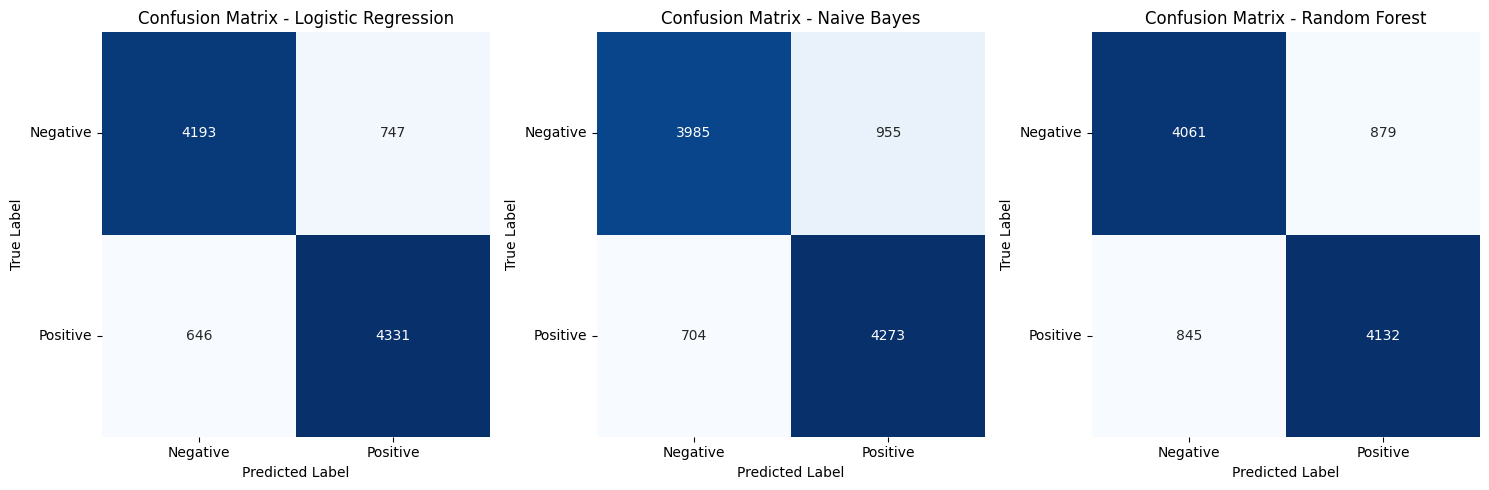

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrices(y_true, predictions, model_names):
    num_models = len(predictions)
    fig, axes = plt.subplots(1, num_models, figsize=(5 * num_models, 5))

    if num_models == 1:
        axes = [axes]

    for i, (preds, name) in enumerate(zip(predictions, model_names)):
        cm = confusion_matrix(y_true, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i])
        axes[i].set_title(f'Confusion Matrix - {name}')
        axes[i].set_xlabel('Predicted Label')
        axes[i].set_ylabel('True Label')
        axes[i].set_xticklabels(['Negative', 'Positive'])
        axes[i].set_yticklabels(['Negative', 'Positive'], rotation=0)

    plt.tight_layout()
    plt.show()

# Prepare predictions and model names
all_predictions = [lr_pred, nb_pred, rf_pred]
model_names = ['Logistic Regression', 'Naive Bayes', 'Random Forest', 'SVM']

# Plot the confusion matrices
plot_confusion_matrices(y_test, all_predictions, model_names)

**Hyperparamter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid_lr = {
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2']
}

lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
lr_grid.fit(X_train, y_train)

print(f"Best parameters for Logistic Regression: {lr_grid.best_params_}")
print(f"Best cross-validation accuracy for Logistic Regression: {lr_grid.best_score_}")

best_lr_model = lr_grid.best_estimator_
best_lr_pred = best_lr_model.predict(X_test)
best_lr_accuracy = accuracy_score(y_test, best_lr_pred)
print(f"Tuned Logistic Regression Accuracy on test set: {best_lr_accuracy}")
print("Classification Report for Tuned Logistic Regression:\n", classification_report(y_test, best_lr_pred))


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters for Logistic Regression: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation accuracy for Logistic Regression: 0.8598008319677298
Tuned Logistic Regression Accuracy on test set: 0.8598366441464153
Classification Report for Tuned Logistic Regression:
               precision    recall  f1-score   support

           0       0.87      0.85      0.86      4940
           1       0.85      0.87      0.86      4977

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



### Confusion Matrix for Tuned Logistic Regression

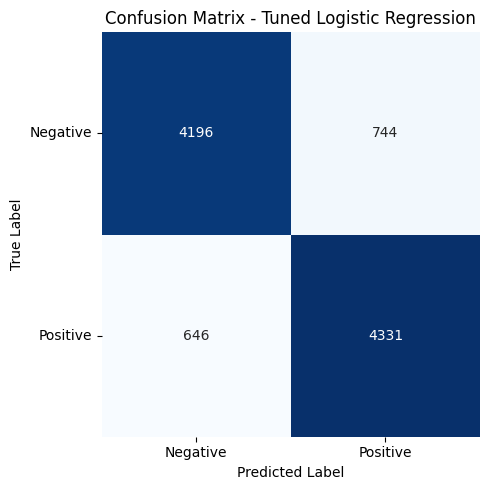

In [ ]:
plot_confusion_matrices(y_test, [best_lr_pred], ['Tuned Logistic Regression'])


The accuracy increased by 0.03%

In [ ]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

print(f"Best parameters for Random Forest: {rf_grid.best_params_}")
print(f"Best cross-validation accuracy for Random Forest: {rf_grid.best_score_}")

best_rf_model = rf_grid.best_estimator_
best_rf_pred = best_rf_model.predict(X_test)
best_rf_accuracy = accuracy_score(y_test, best_rf_pred)
print(f"Tuned Random Forest Accuracy on test set: {best_rf_accuracy}")
print("Classification Report for Tuned Random Forest:\n", classification_report(y_test, best_rf_pred))


Fitting 3 folds for each of 36 candidates, totalling 108 fits


### Confusion Matrix for Tuned Random Forest

In [ ]:
plot_confusion_matrices(y_test, [best_rf_pred], ['Tuned Random Forest'])
